## Neuro Representation Learning with AraBERT

A pretrained transformer encoder (AraBERT) is employed to capture
deep contextual semantic representations of Arabic sequences.

The model pipeline includes:

1. Transformer sequence encoding
2. Extraction of the [CLS] contextual embedding
3. Dropout regularization layer
4. Sigmoid classification head for binary simile prediction

Binary cross-entropy loss and Adam optimization are used for training.

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.model_selection import train_test_split
from transformers import DataCollatorWithPadding
from arabert.preprocess import ArabertPreprocessor
from transformers import TFAutoModel
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

/Users/roamsaleh/Library/Python/3.9/lib/python/site-packages/google/api_core/_python_version_support.py:246: FutureWarning: You are using a non-supported Python version (3.9.6). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)


In [1]:
from symbolic_model import build_symbolic_matrix


In [3]:
ModelName = "aubmindlab/bert-large-arabertv02"
MAX_LEN = 120
BATCH_SIZE = 16
EPOCHS = 10
SEED = 42


tf.random.set_seed(SEED)
np.random.seed(SEED)

In [ ]:
# import pandas as pd

# df = pd.read_csv("cleaned_cleaned_")

# sentences = df["sentence"].tolist()
# labels = df["label"].tolist()

In [4]:
train_df = pd.read_csv("/Users/roamsaleh/Downloads/binary_files/cleaned_train.csv")
val_df   = pd.read_csv("/Users/roamsaleh/Downloads/binary_files/cleaned_val.csv")
test_df  = pd.read_csv("/Users/roamsaleh/Downloads/binary_files/cleaned_test.csv")

In [5]:
X_train = train_df["text"].tolist()
y_train = train_df["label"].tolist()

X_val = val_df["text"].tolist()
y_val = val_df["label"].tolist()

X_test = test_df["text"].tolist()
y_test = test_df["label"].tolist()

In [6]:
print(len(X_train), len(X_val), len(X_test))

3200 400 400


In [7]:
# X_train_val, X_test, y_train_val, y_test = train_test_split(sentences, labels, test_size=0.1, random_state=SEED)
# X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1, random_state=SEED)
X_train_sym = build_symbolic_matrix(X_train)
X_val_sym = build_symbolic_matrix(X_val)
X_test_sym = build_symbolic_matrix(X_test)
arabert_prep = ArabertPreprocessor(model_name=ModelName)
tokenizer = AutoTokenizer.from_pretrained(ModelName)

def PreprocessTexts(texts):
    texts = [arabert_prep.preprocess(text) for text in texts]
    encodings = tokenizer(
        texts,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='tf'
    )
    return encodings['input_ids'], encodings['attention_mask']

X_train_ids, X_train_mask =PreprocessTexts(X_train)
X_val_ids, X_val_mask =PreprocessTexts(X_val)
X_test_ids, X_test_mask =PreprocessTexts(X_test)

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


In [9]:
def create_arabert_model(model_name, max_len):

    word_inputs = tf.keras.Input(shape=(max_len,), dtype=tf.int32, name="input_ids")
    attention_mask = tf.keras.Input(shape=(max_len,), dtype=tf.int32, name="attention_mask")
    sym_input = tf.keras.Input(shape=(11,), dtype=tf.float32, name="symbolic_features")

    arabert = TFAutoModel.from_pretrained(model_name, from_pt=True)
    outputs = arabert(word_inputs, attention_mask=attention_mask)[0]

    # cls = outputs[:, 0, :]
    # sym_proj = tf.keras.layers.Dense(32, activation='relu')(sym_input)
    # combined = tf.keras.layers.Concatenate()([cls, sym_proj])

    # x = tf.keras.layers.Dense(256, activation='relu')(combined)
    cls = outputs[:, 0, :]
    x = tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(cls)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    bert_prob = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    has_structure = sym_input[:, 0:1]
    confidence = sym_input[:, 2:3]
    symbolic_score = has_structure * confidence
    alpha = 0.7
    final_output = alpha * bert_prob + (1 - alpha) * symbolic_score

    model = tf.keras.Model(
        inputs=[word_inputs, attention_mask, sym_input],
        outputs=final_output
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-5),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [11]:
model = create_arabert_model(ModelName, MAX_LEN)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)
history = model.fit(
    {
        "input_ids": X_train_ids,
        "attention_mask": X_train_mask,
        "symbolic_features": X_train_sym
    },
    np.array(y_train),
    validation_data=(
        {
            "input_ids": X_val_ids,
            "attention_mask": X_val_mask,
            "symbolic_features": X_val_sym
        },
        np.array(y_val)
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop]
)


TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.bias', 'cls.predictions.decoder.weight', 'bert.embeddings.position_ids', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClas

Epoch 1/10


2026-03-30 14:19:01.404497: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


200/200 [==============================] - 1709s 9s/step - loss: 4.5934 - accuracy: 0.7306 - val_loss: 4.3290 - val_accuracy: 0.9000
Epoch 2/10
200/200 [==============================] - 1719s 9s/step - loss: 4.2778 - accuracy: 0.8853 - val_loss: 4.1534 - val_accuracy: 0.9250
Epoch 3/10
200/200 [==============================] - 1734s 9s/step - loss: 4.1198 - accuracy: 0.9159 - val_loss: 4.0378 - val_accuracy: 0.9400
Epoch 4/10
200/200 [==============================] - 1741s 9s/step - loss: 3.9722 - accuracy: 0.9391 - val_loss: 3.9117 - val_accuracy: 0.9400
Epoch 5/10
200/200 [==============================] - 1740s 9s/step - loss: 3.8265 - accuracy: 0.9572 - val_loss: 3.7957 - val_accuracy: 0.9475
Epoch 6/10
200/200 [==============================] - 1762s 9s/step - loss: 3.6971 - accuracy: 0.9669 - val_loss: 3.6824 - val_accuracy: 0.9475
Epoch 7/10
200/200 [==============================] - 1770s 9s/step - loss: 3.5657 - accuracy: 0.9706 - val_loss: 3.5579 - val_accuracy: 0.9550
Epo

In [14]:
y_pred_prob = model.predict({
    "input_ids": X_test_ids,
    "attention_mask": X_test_mask,
    "symbolic_features": X_test_sym
})

y_pred = (y_pred_prob > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

13/13 [==============================] - 56s 4s/step
[[181  16]
 [  4 199]]
              precision    recall  f1-score   support

           0       0.98      0.92      0.95       197
           1       0.93      0.98      0.95       203

    accuracy                           0.95       400
   macro avg       0.95      0.95      0.95       400
weighted avg       0.95      0.95      0.95       400



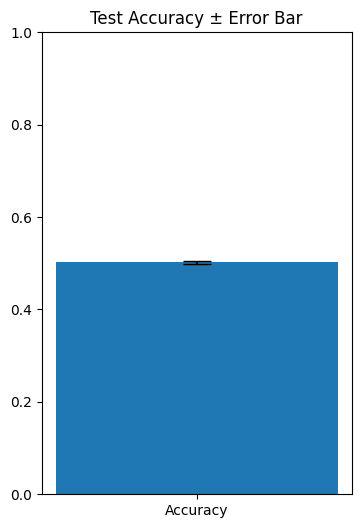

In [16]:
n_bootstraps = 100
accs = []
y_test = np.array(y_test)

for _ in range(n_bootstraps):
    idx = np.random.choice(len(y_test), len(y_test), replace=True)
    acc = np.mean(y_test[idx] == y_pred[idx])
    accs.append(acc)

mean_acc = np.mean(accs)
std_acc = np.std(accs)

plt.figure(figsize=(4,6))
plt.bar(['Accuracy'], [mean_acc], yerr=[std_acc], capsize=10)
plt.ylim(0, 1)
plt.title("Test Accuracy ± Error Bar")
plt.show()